In [27]:
!pip install nltk

In [28]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

# Library untuk data manipulation
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm

# Library untuk text similarity
from sklearn.metrics.pairwise import cosine_similarity

In [9]:
data = pd.read_csv('hasil_crowling.csv')
data

,Judul,Tanggal,Ringkasan,Kategori
0,"Viral Sopir Truk Nekat Lawan Arah di Jakut, Po...",16 Okt 2024 18:04,Dalam rekaman yang diunggah terlihat sopir tru...,Peristiwa
1,Polisi Pastikan 2 Tersangka Pencabulan di Pant...,16 Okt 2024 18:02,"Kabid Humas Polda Metro Jaya, Kombes Pol Ade A...",Peristiwa
2,Sejumlah Tokoh dan Pakar Siap Sukseskan Pelant...,16 Okt 2024 16:05,Mulusnya transisi pemerintahan dapat menjaga s...,Politik
3,"Kasus Emas Antam, Saksi Sebut Budi Said Lakuka...",16 Okt 2024 16:01,"Mantan Manajer Retail PT Antam, Nuning Septi W...",Peristiwa
4,5 Fakta Terkait Budi Gunawan Diberhentikan dar...,16 Okt 2024 16:00,Dewan Perwakilan Rakyat (DPR) RI telah menerim...,Peristiwa
5,"Pramono: Semua Ketum Parpol Teman Saya, Nanti ...",16 Okt 2024 15:51,"Calon Gubernur Jakarta, Pramono Anung mengaku ...",News
6,DPR Minta Herindra Bisa Netral saat Sudah Resm...,16 Okt 2024 15:41,"Kepada Herindra, Puan menitipkan pesan khusus ...",Peristiwa
7,"Pengamat Nilai Jika SK-ADT Pimpin Sulut, Dukun...",16 Okt 2024 15:25,Pengamat politik dan pemerintahan Sulawesi Uta...,Politik
8,"Cegah Banjir Terulang, Pramono Bakal Bebaskan ...",16 Okt 2024 15:22,Untuk mengatasi banjir di daerah bantaran kali...,News
9,Puan Maharani Masih Irit Bicara soal Pertemuan...,16 Okt 2024 15:03,"Ketua DPP PDI Perjuangan, Puan Maharani belum ...",Politik


In [10]:
def clean_text(text):
	text = re.sub(r'((www\.[^\s]+)|(https?://[^\s]+))', ' ', text) # Menghapus https* and www*
	text = re.sub(r'@[^\s]+', ' ', text) # Menghapus username
	text = re.sub(r'[\s]+', ' ', text) # Menghapus tambahan spasi
	text = re.sub(r'#([^\s]+)', ' ', text) # Menghapus hashtags
	text = re.sub(r"[^a-zA-Z : .]", "", text) # Menghapus tanda baca
	text = re.sub(r'\d', ' ', text) # Menghapus angka
	text = text.lower()
	text = text.encode('ascii','ignore').decode('utf-8') #Menghapus ASCII dan unicode
	text = re.sub(r'[^\x00-\x7f]',r'', text)
	text = text.replace('\n','') #Menghapus baris baru
	text = text.strip()
	return text

def clean_stopword(tokens):
	listStopword =  set(stopwords.words('indonesian'))
	filtered_words = [word for word in tokens if word.lower() not in listStopword]
	return filtered_words

In [13]:
import nltk
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
import pandas as pd
from tqdm import tqdm

# Download stopwords jika belum diunduh
nltk.download('stopwords')

# Fungsi untuk membersihkan teks
def clean_text(text):
    text = re.sub(r'((www\.[^\s]+)|(https?://[^\s]+))', ' ', text)  # Menghapus https* and www*
    text = re.sub(r'@[^\s]+', ' ', text)  # Menghapus username
    text = re.sub(r'[\s]+', ' ', text)  # Menghapus tambahan spasi
    text = re.sub(r'#([^\s]+)', ' ', text)  # Menghapus hashtags
    text = re.sub(r"[^a-zA-Z :\.]", "", text)  # Menghapus tanda baca
    text = re.sub(r'\d', ' ', text)  # Menghapus angka
    text = text.lower()
    text = text.encode('ascii', 'ignore').decode('utf-8')  # Menghapus ASCII dan unicode
    text = re.sub(r'[^\x00-\x7f]', r'', text)
    text = text.replace('\n', '')  # Menghapus baris baru
    text = text.strip()
    return text

# Fungsi untuk membersihkan stopwords
def clean_stopword(tokens):
    listStopword = set(stopwords.words('indonesian'))
    filtered_words = [word for word in tokens if word.lower() not in listStopword]
    return filtered_words

# Fungsi untuk memproses teks
def preprocess_text(content):
    result = {}
    for i, text in enumerate(tqdm(content)):
        cleaned_text = clean_text(text)
        tokens = word_tokenize(cleaned_text)
        cleaned_stopword = clean_stopword(tokens)
        result[i] = ' '.join(cleaned_stopword)
    return result

# Misalnya, data adalah DataFrame yang berisi kolom 'Ringkasan'
data = pd.read_csv('hasil_crowling.csv')  # Ganti dengan file yang sesuai
data['cleaned_news'] = preprocess_text(data['Ringkasan'])
print(data)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
100%|██████████| 53/53 [00:00<00:00, 864.49it/s]

                                                Judul            Tanggal  \
0   Viral Sopir Truk Nekat Lawan Arah di Jakut, Po...  16 Okt 2024 18:04   
1   Polisi Pastikan 2 Tersangka Pencabulan di Pant...  16 Okt 2024 18:02   
2   Sejumlah Tokoh dan Pakar Siap Sukseskan Pelant...  16 Okt 2024 16:05   
3   Kasus Emas Antam, Saksi Sebut Budi Said Lakuka...  16 Okt 2024 16:01   
4   5 Fakta Terkait Budi Gunawan Diberhentikan dar...  16 Okt 2024 16:00   
5   Pramono: Semua Ketum Parpol Teman Saya, Nanti ...  16 Okt 2024 15:51   
6   DPR Minta Herindra Bisa Netral saat Sudah Resm...  16 Okt 2024 15:41   
7   Pengamat Nilai Jika SK-ADT Pimpin Sulut, Dukun...  16 Okt 2024 15:25   
8   Cegah Banjir Terulang, Pramono Bakal Bebaskan ...  16 Okt 2024 15:22   
9   Puan Maharani Masih Irit Bicara soal Pertemuan...  16 Okt 2024 15:03   
10  Selama 3 Hari, 768 Pengendara Terjaring Operas...  16 Okt 2024 15:02   
11  Pemberantasan Korupsi Jadi Tantangan Pemerinta...  16 Okt 2024 15:01   
12  Transaks

In [14]:
kalimat = nltk.sent_tokenize(data['cleaned_news'][39])
kalimat = [sentence.replace('.', '') for sentence in kalimat]
kata = nltk.word_tokenize(data['cleaned_news'][39])
kata = list(set(k for k in kata if k != '.'))

In [15]:
kalimat

['operasi zebra jaya rangka pengamanan jelang pelantikan presiden wapres terpilih prabowo subiantogibran rakabuming raka oktober ',
 'operasi wilayah hukum polda metro jaya oktober ']

In [16]:
kata

['zebra',
 'operasi',
 'jaya',
 'subiantogibran',
 'polda',
 'presiden',
 'rangka',
 'metro',
 'wapres',
 'oktober',
 'raka',
 'prabowo',
 'pengamanan',
 'hukum',
 'wilayah',
 'jelang',
 'terpilih',
 'rakabuming',
 'pelantikan']

In [17]:
def vektor_kata(data):
	vektor_kata = pd.DataFrame(0, index=range(len(data)), columns=kata)

	for i, sent in enumerate(data):
		# Tokenisasi kalimat menjadi kata-kata
		kata_kalimat = word_tokenize(sent)

		# Hitung frekuensi setiap kata dalam kalimat
		for word in kata_kalimat:
			if word in kata:
				vektor_kata.at[i, word] += 1

	return vektor_kata

In [18]:
df_vektor_kata = vektor_kata(kalimat)
df_vektor_kata

,zebra,operasi,jaya,subiantogibran,polda,presiden,rangka,metro,wapres,oktober,raka,prabowo,pengamanan,hukum,wilayah,jelang,terpilih,rakabuming,pelantikan
0,1,1,1,1,0,1,1,0,1,1,1,1,1,0,0,1,1,1,1
1,0,1,1,0,1,0,0,1,0,1,0,0,0,1,1,0,0,0,0


In [19]:
sorted_kata = df_vektor_kata.sum().sort_values(ascending=False)[:3]
print(", ".join(sorted_kata.index))

oktober, jaya, operasi


In [20]:
def create_cooccurrence_matrix(data):
	vektor_kata = pd.DataFrame(0, index=kata, columns=kata)

	for sent in data:
		kata_kalimat = word_tokenize(sent)
		for i in range(len(kata_kalimat)-1):
			vektor_kata.at[kata_kalimat[i], kata_kalimat[i+1]] += 1
			vektor_kata.at[kata_kalimat[i+1], kata_kalimat[i]] += 1

	return vektor_kata

cooccurrence_matrix = create_cooccurrence_matrix(kalimat)
cooccurrence_matrix

,zebra,operasi,jaya,subiantogibran,polda,presiden,rangka,metro,wapres,oktober,raka,prabowo,pengamanan,hukum,wilayah,jelang,terpilih,rakabuming,pelantikan
zebra,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
operasi,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
jaya,1,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0
subiantogibran,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
polda,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
presiden,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1
rangka,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
metro,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
wapres,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
oktober,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


In [21]:
cossim = cosine_similarity(cooccurrence_matrix)

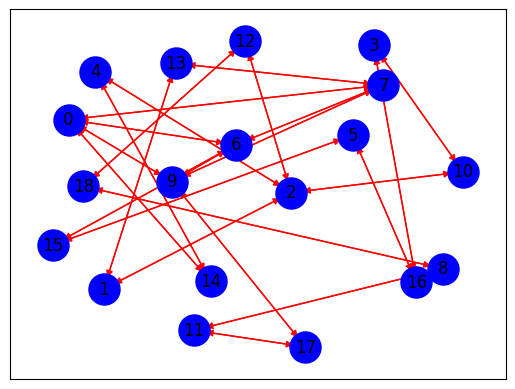

In [22]:
G = nx.DiGraph()
for i in range(len(cossim)):
    G.add_node(i)

for i in range(len(cossim)):
    for j in range(len(cossim)):
        similarity = cossim[i][j]
        if similarity > 0.1 and i != j:
            G.add_edge(i, j)

pos = nx.spring_layout(G, k=2)
nx.draw_networkx_nodes(G, pos, node_size=500, node_color='b')
nx.draw_networkx_edges(G, pos, edge_color='red', arrows=True)
nx.draw_networkx_labels(G, pos)

plt.show()

In [23]:
pagerank = nx.pagerank(G)

sorted_pagerank= sorted(pagerank.items(), key=lambda x: x[1], reverse=True)
print("Page Rank :")
for node, pagerank in sorted_pagerank:
    print(f"Node {node}: {pagerank:.4f}")

Page Rank :
Node 2: 0.0838
Node 6: 0.0714
Node 9: 0.0714
Node 0: 0.0709
Node 7: 0.0709
Node 8: 0.0480
Node 16: 0.0480
Node 3: 0.0479
Node 18: 0.0479
Node 5: 0.0465
Node 11: 0.0465
Node 10: 0.0461
Node 12: 0.0461
Node 1: 0.0433
Node 4: 0.0433
Node 15: 0.0428
Node 17: 0.0428
Node 13: 0.0413
Node 14: 0.0413


In [24]:
print("Tiga Node Tertinggi Page Rank :")
sentence = ""
for node, pagerank in sorted_pagerank[:3]:
  top_sentence = kata[node]
  sentence += top_sentence + ", "
  print(f"Node {node}: Page Rank = {pagerank:.4f}")
  print(f"Kalimat: {top_sentence}")

Tiga Node Tertinggi Page Rank :
Node 2: Page Rank = 0.0838
Kalimat: jaya
Node 6: Page Rank = 0.0714
Kalimat: rangka
Node 9: Page Rank = 0.0714
Kalimat: oktober


In [25]:
import streamlit as st
import pickle
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Judul aplikasi
st.title("Analisis PageRank dengan Streamlit")

# Deskripsi aplikasi
st.write("Aplikasi ini menganalisis PageRank dari sebuah grafik berbasis teks.")

# Pilihan untuk memuat model
uploaded_file = st.file_uploader("Upload File Pickle Model PageRank", type=["pkl"])

if uploaded_file:
    # Load model PageRank
    pagerank_model = pickle.load(uploaded_file)

    # Tampilkan PageRank
    st.subheader("Hasil PageRank")
    sorted_pagerank = sorted(pagerank_model.items(), key=lambda x: x[1], reverse=True)
    for node, rank in sorted_pagerank[:10]:
        st.write(f"Node {node}: {rank:.4f}")

    # Grafik visualisasi (contoh sederhana)
    G = nx.DiGraph()
    for node, rank in pagerank_model.items():
        G.add_node(node, size=rank * 100)

    pos = nx.spring_layout(G, k=0.5)
    plt.figure(figsize=(10, 7))
    nx.draw(G, pos, with_labels=True, node_size=[v * 5000 for v in pagerank_model.values()])
    plt.title("Visualisasi Graph")
    st.pyplot(plt)


ModuleNotFoundError: No module named 'streamlit'

In [26]:
import pickle

# Simpan PageRank ke dalam file pickle
pagerank_model = nx.pagerank(G)

with open('pagerank_model.pkl', 'wb') as file:
    pickle.dump(pagerank_model, file)

print("Model PageRank berhasil disimpan ke pagerank_model.pkl")


Model PageRank berhasil disimpan ke pagerank_model.pkl


Link Deployment : https://huggingface.co/spaces/22-065/ppwtugas6